# Creación e implementación de un Data Warehouse usando PostgreSQL y Jupyter Notebook con Python

**Asignatura:** Extracción del conocimiento de Bases de Datos  
**Producto:** Primer parcial  
**Alumno:** Abiel Ontiveros Calvario  
**Grupo:** 9.º B  
**Herramientas:** Anaconda, Jupyter Notebook, Python, pandas, SQLAlchemy, PostgreSQL, pgAdmin y Matplotlib  
**Base de datos:** `dw_ventas`

## Descripción general

En esta práctica se desarrolla un Data Warehouse de ventas utilizando PostgreSQL como sistema gestor de base de datos y Jupyter Notebook, ejecutado desde Anaconda, como entorno de procesamiento y análisis.

La práctica cubre el flujo completo de trabajo: preparación del entorno, conexión con PostgreSQL, creación del modelo dimensional, simulación de datos, generación e importación de archivos CSV, validación, transformación, carga, consultas analíticas y visualización de indicadores.

In [1]:
pip install sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

In [3]:
# Parámetros de conexión con PostgreSQL
usuario = "postgres"
password = "12345"
host = "localhost"
puerto = "5432"
base_datos = "dw_ventas"

In [4]:
# Creación del motor de conexión
engine = create_engine(
    f"postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{base_datos}"
)

In [5]:
# Validación de la conexión
pd.read_sql("SELECT version() AS version_postgresql;", engine)

,version_postgresql
0,"PostgreSQL 18.1 on x86_64-windows, compiled by..."


In [6]:
# Eliminación de tablas anteriores

with engine.begin() as conexion:
    conexion.execute(text("DROP TABLE IF EXISTS hecho_ventas CASCADE;"))
    conexion.execute(text("DROP TABLE IF EXISTS dim_cliente CASCADE;"))
    conexion.execute(text("DROP TABLE IF EXISTS dim_producto CASCADE;"))
    conexion.execute(text("DROP TABLE IF EXISTS dim_region CASCADE;"))
    conexion.execute(text("DROP TABLE IF EXISTS dim_tiempo CASCADE;"))

In [7]:
# Creación de la dimensión cliente
with engine.begin() as conexion:
    conexion.execute(text("""
        CREATE TABLE dim_cliente (
            id_cliente INTEGER PRIMARY KEY,
            nombre_cliente VARCHAR(100) NOT NULL,
            genero VARCHAR(20),
            edad INTEGER CHECK (edad >= 0)
        );
    """))

In [8]:
# Creación de la dimensión producto
with engine.begin() as conexion:
    conexion.execute(text("""
        CREATE TABLE dim_producto (
            id_producto INTEGER PRIMARY KEY,
            nombre_producto VARCHAR(100) NOT NULL,
            categoria VARCHAR(50) NOT NULL,
            precio_unitario NUMERIC(10,2) NOT NULL CHECK (precio_unitario >= 0)
        );
    """))

In [9]:
# Creación de la dimensión región
with engine.begin() as conexion:
    conexion.execute(text("""
        CREATE TABLE dim_region (
            id_region INTEGER PRIMARY KEY,
            region VARCHAR(50) NOT NULL,
            ciudad VARCHAR(50) NOT NULL
        );
    """))

In [10]:
# Creación de la dimensión tiempo
with engine.begin() as conexion:
    conexion.execute(text("""
        CREATE TABLE dim_tiempo (
            id_tiempo INTEGER PRIMARY KEY,
            fecha DATE NOT NULL,
            mes VARCHAR(20) NOT NULL,
            anio INTEGER NOT NULL
        );
    """))

In [11]:
# Creación de la tabla de hechos
with engine.begin() as conexion:
    conexion.execute(text("""
        CREATE TABLE hecho_ventas (
            id_venta INTEGER PRIMARY KEY,
            id_cliente INTEGER NOT NULL,
            id_producto INTEGER NOT NULL,
            id_region INTEGER NOT NULL,
            id_tiempo INTEGER NOT NULL,
            cantidad INTEGER NOT NULL CHECK (cantidad > 0),
            total_venta NUMERIC(12,2) NOT NULL CHECK (total_venta >= 0),

            CONSTRAINT fk_hecho_cliente
                FOREIGN KEY (id_cliente)
                REFERENCES dim_cliente(id_cliente),

            CONSTRAINT fk_hecho_producto
                FOREIGN KEY (id_producto)
                REFERENCES dim_producto(id_producto),

            CONSTRAINT fk_hecho_region
                FOREIGN KEY (id_region)
                REFERENCES dim_region(id_region),

            CONSTRAINT fk_hecho_tiempo
                FOREIGN KEY (id_tiempo)
                REFERENCES dim_tiempo(id_tiempo)
        );
    """))

In [12]:
# Verificación de las tablas creadas

tablas_creadas = pd.read_sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'public'
    ORDER BY table_name;
""", engine)

tablas_creadas

,table_name
0,dim_cliente
1,dim_producto
2,dim_region
3,dim_tiempo
4,hecho_ventas


In [13]:
# Creación del conjunto de datos de clientes
# Cada registro representa un cliente único identificado por id_cliente.

clientes = pd.DataFrame({
    "id_cliente": [1, 2, 3, 4, 5],
    "nombre_cliente": [
        "Ana López",
        "Carlos Pérez",
        "María García",
        "Luis Torres",
        "Sofía Hernández"
    ],
    "genero": [
        "Femenino",
        "Masculino",
        "Femenino",
        "Masculino",
        "Femenino"
    ],
    "edad": [22, 35, 29, 41, 31]
})

clientes

,id_cliente,nombre_cliente,genero,edad
0,1,Ana López,Femenino,22
1,2,Carlos Pérez,Masculino,35
2,3,María García,Femenino,29
3,4,Luis Torres,Masculino,41
4,5,Sofía Hernández,Femenino,31


In [14]:
# Creación del conjunto de datos de productos
# Se incluyen nombre, categoría y precio unitario.

productos = pd.DataFrame({
    "id_producto": [1, 2, 3, 4, 5],
    "nombre_producto": [
        "Laptop",
        "Mouse",
        "Teclado",
        "Monitor",
        "Impresora"
    ],
    "categoria": [
        "Cómputo",
        "Accesorio",
        "Accesorio",
        "Cómputo",
        "Oficina"
    ],
    "precio_unitario": [12000.00, 250.00, 600.00, 3500.00, 2800.00]
})

productos

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Laptop,Cómputo,12000.0
1,2,Mouse,Accesorio,250.0
2,3,Teclado,Accesorio,600.0
3,4,Monitor,Cómputo,3500.0
4,5,Impresora,Oficina,2800.0


In [15]:
# Creación del conjunto de datos de regiones
# Cada región se relaciona con una ciudad representativa.

regiones = pd.DataFrame({
    "id_region": [1, 2, 3, 4],
    "region": ["Norte", "Sur", "Centro", "Este"],
    "ciudad": ["Monterrey", "Veracruz", "Ciudad de México", "Puebla",]
})

regiones

,id_region,region,ciudad
0,1,Norte,Monterrey
1,2,Sur,Veracruz
2,3,Centro,Ciudad de México
3,4,Este,Puebla


In [16]:
# Creación del conjunto de datos de tiempo
tiempo = pd.DataFrame({
    "id_tiempo": [1, 2, 3, 4, 5, 6],
    "fecha": [
        "2026-01-10",
        "2026-02-15",
        "2026-03-20",
        "2026-04-12",
        "2026-05-18",
        "2026-06-05"
    ],
    "mes": ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio"],
    "anio": [2026, 2026, 2026, 2026, 2026, 2026]
})

tiempo

,id_tiempo,fecha,mes,anio
0,1,2026-01-10,Enero,2026
1,2,2026-02-15,Febrero,2026
2,3,2026-03-20,Marzo,2026
3,4,2026-04-12,Abril,2026
4,5,2026-05-18,Mayo,2026
5,6,2026-06-05,Junio,2026


In [17]:
# Creación del conjunto de datos de ventas
# Se registran las claves de las dimensiones y la cantidad vendida.
# El total de venta se calculará en una etapa posterior.

ventas = pd.DataFrame({
    "id_venta": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "id_cliente": [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    "id_producto": [1, 2, 3, 4, 5, 2, 3, 1, 5, 4],
    "id_region": [1, 2, 3, 4, 1, 2, 3, 4, 2, 1],
    "id_tiempo": [1, 2, 3, 4, 5, 6, 1, 2, 3, 4],
    "cantidad": [2, 5, 3, 1, 2, 4, 6, 1, 3, 2]
})

ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad
0,1,1,1,1,1,2
1,2,2,2,2,2,5
2,3,3,3,3,3,3
3,4,4,4,4,4,1
4,5,5,5,1,5,2
5,6,1,2,2,6,4
6,7,2,3,3,1,6
7,8,3,1,4,2,1
8,9,4,5,2,3,3
9,10,5,4,1,4,2


In [18]:
# Incorporación del precio unitario a las venta
ventas = ventas.merge(
    productos[["id_producto", "precio_unitario"]],
    on="id_producto",
    how="left"
)

ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,precio_unitario
0,1,1,1,1,1,2,12000.0
1,2,2,2,2,2,5,250.0
2,3,3,3,3,3,3,600.0
3,4,4,4,4,4,1,3500.0
4,5,5,5,1,5,2,2800.0
5,6,1,2,2,6,4,250.0
6,7,2,3,3,1,6,600.0
7,8,3,1,4,2,1,12000.0
8,9,4,5,2,3,3,2800.0
9,10,5,4,1,4,2,3500.0


In [19]:
# Cálculo del total de venta
ventas["total_venta"] = (
    ventas["cantidad"] * ventas["precio_unitario"]
).round(2)

ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,precio_unitario,total_venta
0,1,1,1,1,1,2,12000.0,24000.0
1,2,2,2,2,2,5,250.0,1250.0
2,3,3,3,3,3,3,600.0,1800.0
3,4,4,4,4,4,1,3500.0,3500.0
4,5,5,5,1,5,2,2800.0,5600.0
5,6,1,2,2,6,4,250.0,1000.0
6,7,2,3,3,1,6,600.0,3600.0
7,8,3,1,4,2,1,12000.0,12000.0
8,9,4,5,2,3,3,2800.0,8400.0
9,10,5,4,1,4,2,3500.0,7000.0


In [20]:
# Eliminación de la columna auxiliar precio_unitario
# El precio pertenece a dim_producto; hecho_ventas conserva total_venta.

ventas = ventas.drop(columns=["precio_unitario"])

ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000.0
1,2,2,2,2,2,5,1250.0
2,3,3,3,3,3,3,1800.0
3,4,4,4,4,4,1,3500.0
4,5,5,5,1,5,2,5600.0
5,6,1,2,2,6,4,1000.0
6,7,2,3,3,1,6,3600.0
7,8,3,1,4,2,1,12000.0
8,9,4,5,2,3,3,8400.0
9,10,5,4,1,4,2,7000.0


In [21]:
# Exportación de los conjuntos de datos a formato CSV
clientes.to_csv("clientes.csv", index=False, encoding="utf-8-sig")
productos.to_csv("productos.csv", index=False, encoding="utf-8-sig")
regiones.to_csv("regiones.csv", index=False, encoding="utf-8-sig")
tiempo.to_csv("tiempo.csv", index=False, encoding="utf-8-sig")
ventas.to_csv("ventas.csv", index=False, encoding="utf-8-sig")

In [22]:
# Verificación de los archivos generados

archivos_generados = pd.DataFrame({
    "archivo": [
        "clientes.csv",
        "productos.csv",
        "regiones.csv",
        "tiempo.csv",
        "ventas.csv"
    ],
    "contenido": [
        "Datos de clientes",
        "Catálogo de productos",
        "Catálogo de regiones",
        "Calendario de análisis",
        "Operaciones de venta"
    ]
})

archivos_generados

,archivo,contenido
0,clientes.csv,Datos de clientes
1,productos.csv,Catálogo de productos
2,regiones.csv,Catálogo de regiones
3,tiempo.csv,Calendario de análisis
4,ventas.csv,Operaciones de venta


In [23]:
# Importación del archivo de clientes

df_clientes = pd.read_csv("clientes.csv")

df_clientes

,id_cliente,nombre_cliente,genero,edad
0,1,Ana López,Femenino,22
1,2,Carlos Pérez,Masculino,35
2,3,María García,Femenino,29
3,4,Luis Torres,Masculino,41
4,5,Sofía Hernández,Femenino,31


In [24]:
# Importación del archivo de productos

df_productos = pd.read_csv("productos.csv")

df_productos

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Laptop,Cómputo,12000.0
1,2,Mouse,Accesorio,250.0
2,3,Teclado,Accesorio,600.0
3,4,Monitor,Cómputo,3500.0
4,5,Impresora,Oficina,2800.0


In [25]:
# Importación del archivo de regiones

df_regiones = pd.read_csv("regiones.csv")

df_regiones

,id_region,region,ciudad
0,1,Norte,Monterrey
1,2,Sur,Veracruz
2,3,Centro,Ciudad de México
3,4,Este,Puebla


In [26]:
# Importación del archivo de tiempo

df_tiempo = pd.read_csv("tiempo.csv")

df_tiempo

,id_tiempo,fecha,mes,anio
0,1,2026-01-10,Enero,2026
1,2,2026-02-15,Febrero,2026
2,3,2026-03-20,Marzo,2026
3,4,2026-04-12,Abril,2026
4,5,2026-05-18,Mayo,2026
5,6,2026-06-05,Junio,2026


In [27]:
# Importación del archivo de ventas

df_ventas = pd.read_csv("ventas.csv")

df_ventas

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000.0
1,2,2,2,2,2,5,1250.0
2,3,3,3,3,3,3,1800.0
3,4,4,4,4,4,1,3500.0
4,5,5,5,1,5,2,5600.0
5,6,1,2,2,6,4,1000.0
6,7,2,3,3,1,6,3600.0
7,8,3,1,4,2,1,12000.0
8,9,4,5,2,3,3,8400.0
9,10,5,4,1,4,2,7000.0


In [28]:
# Revisión del tamaño del conjunto de ventas
df_ventas.shape

(10, 7)

In [29]:
# Revisión de columnas disponibles

df_ventas.columns

Index(['id_venta', 'id_cliente', 'id_producto', 'id_region', 'id_tiempo',
       'cantidad', 'total_venta'],
      dtype='object')

In [30]:
# Revisión de tipos de datos y valores no nulos

df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     10 non-null     int64  
 1   id_cliente   10 non-null     int64  
 2   id_producto  10 non-null     int64  
 3   id_region    10 non-null     int64  
 4   id_tiempo    10 non-null     int64  
 5   cantidad     10 non-null     int64  
 6   total_venta  10 non-null     float64
dtypes: float64(1), int64(6)
memory usage: 692.0 bytes


In [31]:
# Validación de valores nulos en clientes

df_clientes.isna().sum()

id_cliente        0
nombre_cliente    0
genero            0
edad              0
dtype: int64

In [32]:
# Validación de valores nulos en productos

df_productos.isna().sum()

id_producto        0
nombre_producto    0
categoria          0
precio_unitario    0
dtype: int64

In [33]:
# Validación de valores nulos en regiones

df_regiones.isna().sum()

id_region    0
region       0
ciudad       0
dtype: int64

In [34]:
# Validación de valores nulos en tiempo

df_tiempo.isna().sum()

id_tiempo    0
fecha        0
mes          0
anio         0
dtype: int64

In [35]:
# Validación de valores nulos en ventas

df_ventas.isna().sum()

id_venta       0
id_cliente     0
id_producto    0
id_region      0
id_tiempo      0
cantidad       0
total_venta    0
dtype: int64

In [36]:
# Validación de registros duplicados en clientes

df_clientes.duplicated().sum()

np.int64(0)

In [37]:
# Validación de registros duplicados en productos

df_productos.duplicated().sum()

np.int64(0)

In [38]:
# Validación de registros duplicados en regiones

df_regiones.duplicated().sum()

np.int64(0)

In [39]:
# Validación de registros duplicados en tiempo

df_tiempo.duplicated().sum()

np.int64(0)

In [40]:
# Validación de registros duplicados en ventas

df_ventas.duplicated().sum()

np.int64(0)

In [41]:
# Estadísticas descriptivas de la tabla de ventas

df_ventas.describe()

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
count,10.00000,10.000000,10.000000,10.000000,10.00000,10.00000,10.000000
mean,5.50000,3.000000,3.000000,2.300000,3.10000,2.90000,6815.000000
std,3.02765,1.490712,1.490712,1.159502,1.66333,1.66333,6972.089197
min,1.00000,1.000000,1.000000,1.000000,1.00000,1.00000,1000.000000
25%,3.25000,2.000000,2.000000,1.250000,2.00000,2.00000,2225.000000
50%,5.50000,3.000000,3.000000,2.000000,3.00000,2.50000,4600.000000
75%,7.75000,4.000000,4.000000,3.000000,4.00000,3.75000,8050.000000
max,10.00000,5.000000,5.000000,4.000000,6.00000,6.00000,24000.000000


In [42]:
# Eliminación de registros duplicados

df_clientes = df_clientes.drop_duplicates()
df_productos = df_productos.drop_duplicates()
df_regiones = df_regiones.drop_duplicates()
df_tiempo = df_tiempo.drop_duplicates()
df_ventas = df_ventas.drop_duplicates()

In [43]:
# Conversión de la columna fecha a tipo datetime

df_tiempo["fecha"] = pd.to_datetime(df_tiempo["fecha"])

In [44]:
# Verificación de la estructura de la dimensión tiempo

df_tiempo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id_tiempo  6 non-null      int64         
 1   fecha      6 non-null      datetime64[ns]
 2   mes        6 non-null      object        
 3   anio       6 non-null      int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 324.0+ bytes


In [45]:
# Verificación final de la tabla de ventas transformada

df_ventas.head()

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000.0
1,2,2,2,2,2,5,1250.0
2,3,3,3,3,3,3,1800.0
3,4,4,4,4,4,1,3500.0
4,5,5,5,1,5,2,5600.0


In [46]:
# Eliminación de los registros existentes
# engine.begin administra la transacción y confirma los cambios automáticamente.

with engine.begin() as conexion:
    conexion.execute(text("DELETE FROM hecho_ventas;"))
    conexion.execute(text("DELETE FROM dim_cliente;"))
    conexion.execute(text("DELETE FROM dim_producto;"))
    conexion.execute(text("DELETE FROM dim_region;"))
    conexion.execute(text("DELETE FROM dim_tiempo;"))

In [47]:
# Verificación de que las tablas se encuentran vacías

conteos_antes_carga = pd.read_sql("""
    SELECT 'dim_cliente' AS tabla, COUNT(*) AS registros FROM dim_cliente
    UNION ALL
    SELECT 'dim_producto', COUNT(*) FROM dim_producto
    UNION ALL
    SELECT 'dim_region', COUNT(*) FROM dim_region
    UNION ALL
    SELECT 'dim_tiempo', COUNT(*) FROM dim_tiempo
    UNION ALL
    SELECT 'hecho_ventas', COUNT(*) FROM hecho_ventas;
""", engine)

conteos_antes_carga

,tabla,registros
0,dim_cliente,0
1,dim_producto,0
2,dim_region,0
3,dim_tiempo,0
4,hecho_ventas,0


In [48]:
# Carga de la dimensión cliente

df_clientes.to_sql(
    "dim_cliente",
    engine,
    if_exists="append",
    index=False
)

5

In [49]:
# Carga de la dimensión producto

df_productos.to_sql(
    "dim_producto",
    engine,
    if_exists="append",
    index=False
)

5

In [50]:
# Carga de la dimensión región

df_regiones.to_sql(
    "dim_region",
    engine,
    if_exists="append",
    index=False
)

4

In [51]:
# Carga de la dimensión tiempo

df_tiempo.to_sql(
    "dim_tiempo",
    engine,
    if_exists="append",
    index=False
)

6

In [52]:
# Carga de la tabla de hechos
# Se ejecuta después de las dimensiones para respetar las claves foráneas.

df_ventas.to_sql(
    "hecho_ventas",
    engine,
    if_exists="append",
    index=False
)

10

In [53]:
# Validación de la cantidad de registros cargados

conteos_despues_carga = pd.read_sql("""
    SELECT 'dim_cliente' AS tabla, COUNT(*) AS registros FROM dim_cliente
    UNION ALL
    SELECT 'dim_producto', COUNT(*) FROM dim_producto
    UNION ALL
    SELECT 'dim_region', COUNT(*) FROM dim_region
    UNION ALL
    SELECT 'dim_tiempo', COUNT(*) FROM dim_tiempo
    UNION ALL
    SELECT 'hecho_ventas', COUNT(*) FROM hecho_ventas;
""", engine)

conteos_despues_carga

,tabla,registros
0,dim_cliente,5
1,dim_producto,5
2,dim_region,4
3,dim_tiempo,6
4,hecho_ventas,10


In [54]:
# Consulta directa de la tabla de hechos

pd.read_sql("""
    SELECT *
    FROM hecho_ventas
    ORDER BY id_venta;
""", engine)

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,1,1,1,1,2,24000.0
1,2,2,2,2,2,5,1250.0
2,3,3,3,3,3,3,1800.0
3,4,4,4,4,4,1,3500.0
4,5,5,5,1,5,2,5600.0
5,6,1,2,2,6,4,1000.0
6,7,2,3,3,1,6,3600.0
7,8,3,1,4,2,1,12000.0
8,9,4,5,2,3,3,8400.0
9,10,5,4,1,4,2,7000.0


In [55]:
# Consulta general uniendo hechos y dimensiones

reporte_general = pd.read_sql("""
    SELECT
        v.id_venta,
        c.nombre_cliente,
        c.genero,
        c.edad,
        p.nombre_producto,
        p.categoria,
        p.precio_unitario,
        r.region,
        r.ciudad,
        t.fecha,
        t.mes,
        t.anio,
        v.cantidad,
        v.total_venta
    FROM hecho_ventas AS v
    INNER JOIN dim_cliente AS c
        ON v.id_cliente = c.id_cliente
    INNER JOIN dim_producto AS p
        ON v.id_producto = p.id_producto
    INNER JOIN dim_region AS r
        ON v.id_region = r.id_region
    INNER JOIN dim_tiempo AS t
        ON v.id_tiempo = t.id_tiempo
    ORDER BY v.id_venta;
""", engine)

reporte_general

,id_venta,nombre_cliente,genero,edad,nombre_producto,categoria,precio_unitario,region,ciudad,fecha,mes,anio,cantidad,total_venta
0,1,Ana López,Femenino,22,Laptop,Cómputo,12000.0,Norte,Monterrey,2026-01-10,Enero,2026,2,24000.0
1,2,Carlos Pérez,Masculino,35,Mouse,Accesorio,250.0,Sur,Veracruz,2026-02-15,Febrero,2026,5,1250.0
2,3,María García,Femenino,29,Teclado,Accesorio,600.0,Centro,Ciudad de México,2026-03-20,Marzo,2026,3,1800.0
3,4,Luis Torres,Masculino,41,Monitor,Cómputo,3500.0,Este,Puebla,2026-04-12,Abril,2026,1,3500.0
4,5,Sofía Hernández,Femenino,31,Impresora,Oficina,2800.0,Norte,Monterrey,2026-05-18,Mayo,2026,2,5600.0
5,6,Ana López,Femenino,22,Mouse,Accesorio,250.0,Sur,Veracruz,2026-06-05,Junio,2026,4,1000.0
6,7,Carlos Pérez,Masculino,35,Teclado,Accesorio,600.0,Centro,Ciudad de México,2026-01-10,Enero,2026,6,3600.0
7,8,María García,Femenino,29,Laptop,Cómputo,12000.0,Este,Puebla,2026-02-15,Febrero,2026,1,12000.0
8,9,Luis Torres,Masculino,41,Impresora,Oficina,2800.0,Sur,Veracruz,2026-03-20,Marzo,2026,3,8400.0
9,10,Sofía Hernández,Femenino,31,Monitor,Cómputo,3500.0,Norte,Monterrey,2026-04-12,Abril,2026,2,7000.0


In [56]:
# Consulta de ventas totales agrupadas por región

ventas_region = pd.read_sql("""
    SELECT
        r.region,
        SUM(v.total_venta) AS total_ventas
    FROM hecho_ventas AS v
    INNER JOIN dim_region AS r
        ON v.id_region = r.id_region
    GROUP BY r.region
    ORDER BY total_ventas DESC;
""", engine)

ventas_region

,region,total_ventas
0,Norte,36600.0
1,Este,15500.0
2,Sur,10650.0
3,Centro,5400.0


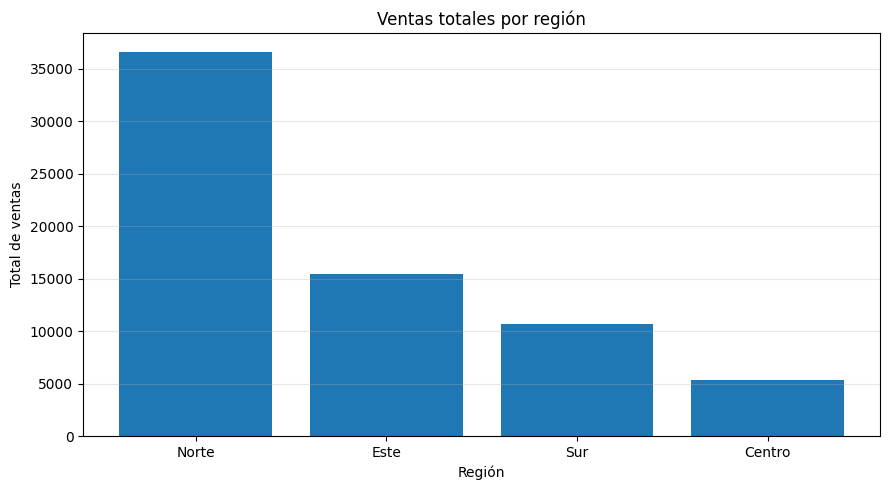

In [57]:
# Gráfica de barras de ventas por región

plt.figure(figsize=(9, 5))
plt.bar(
    ventas_region["region"],
    ventas_region["total_ventas"]
)
plt.title("Ventas totales por región")
plt.xlabel("Región")
plt.ylabel("Total de ventas")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Consulta de productos ordenados por unidades vendidas

productos_vendidos = pd.read_sql("""
    SELECT
        p.nombre_producto,
        SUM(v.cantidad) AS cantidad_vendida
    FROM hecho_ventas AS v
    INNER JOIN dim_producto AS p
        ON v.id_producto = p.id_producto
    GROUP BY p.nombre_producto
    ORDER BY cantidad_vendida DESC;
""", engine)

productos_vendidos

,nombre_producto,cantidad_vendida
0,Teclado,9
1,Mouse,9
2,Impresora,5
3,Monitor,3
4,Laptop,3


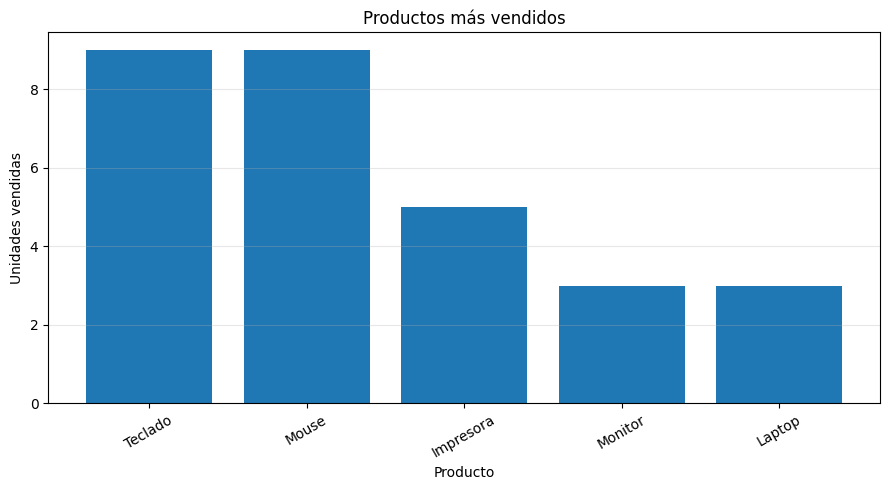

In [59]:
# Gráfica de barras de productos más vendidos

plt.figure(figsize=(9, 5))
plt.bar(
    productos_vendidos["nombre_producto"],
    productos_vendidos["cantidad_vendida"]
)
plt.title("Productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Unidades vendidas")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
# Consulta de ventas agrupadas por mes

ventas_mes = pd.read_sql("""
    SELECT
        t.id_tiempo,
        t.mes,
        t.anio,
        SUM(v.total_venta) AS total_ventas
    FROM hecho_ventas AS v
    INNER JOIN dim_tiempo AS t
        ON v.id_tiempo = t.id_tiempo
    GROUP BY t.id_tiempo, t.mes, t.anio
    ORDER BY t.id_tiempo;
""", engine)

ventas_mes

,id_tiempo,mes,anio,total_ventas
0,1,Enero,2026,27600.0
1,2,Febrero,2026,13250.0
2,3,Marzo,2026,10200.0
3,4,Abril,2026,10500.0
4,5,Mayo,2026,5600.0
5,6,Junio,2026,1000.0


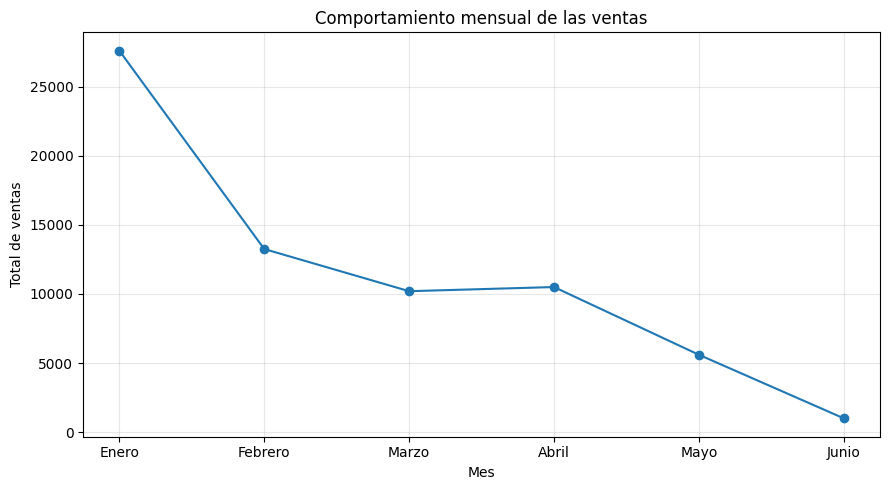

In [61]:
# Gráfica de línea de ventas por mes

plt.figure(figsize=(9, 5))
plt.plot(
    ventas_mes["mes"],
    ventas_mes["total_ventas"],
    marker="o"
)
plt.title("Comportamiento mensual de las ventas")
plt.xlabel("Mes")
plt.ylabel("Total de ventas")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
# Consulta de ventas totales agrupadas por categoría

ventas_categoria = pd.read_sql("""
    SELECT
        p.categoria,
        SUM(v.total_venta) AS total_ventas
    FROM hecho_ventas AS v
    INNER JOIN dim_producto AS p
        ON v.id_producto = p.id_producto
    GROUP BY p.categoria
    ORDER BY total_ventas DESC;
""", engine)

ventas_categoria

,categoria,total_ventas
0,Cómputo,46500.0
1,Oficina,14000.0
2,Accesorio,7650.0


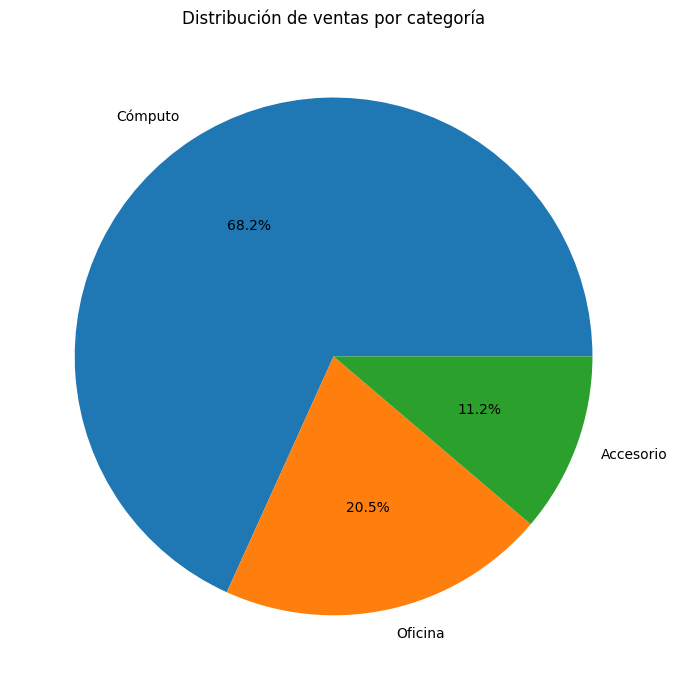

In [63]:
# Gráfica circular de la participación de ventas por categoría

plt.figure(figsize=(7, 7))
plt.pie(
    ventas_categoria["total_ventas"],
    labels=ventas_categoria["categoria"],
    autopct="%1.1f%%"
)
plt.title("Distribución de ventas por categoría")
plt.tight_layout()
plt.show()

In [64]:
# Verificación final de tablas y número de columnas

verificacion_final = pd.read_sql("""
    SELECT
        table_name,
        (
            SELECT COUNT(*)
            FROM information_schema.columns AS c
            WHERE c.table_schema = 'public'
              AND c.table_name = t.table_name
        ) AS numero_columnas
    FROM information_schema.tables AS t
    WHERE table_schema = 'public'
      AND table_name IN (
          'dim_cliente',
          'dim_producto',
          'dim_region',
          'dim_tiempo',
          'hecho_ventas'
      )
    ORDER BY table_name;
""", engine)

verificacion_final

,table_name,numero_columnas
0,dim_cliente,4
1,dim_producto,4
2,dim_region,3
3,dim_tiempo,4
4,hecho_ventas,7


In [65]:
# Resumen de los principales indicadores obtenidos

resumen_indicadores = pd.DataFrame({
    "indicador": [
        "Total de ventas registradas",
        "Ingreso total",
        "Clientes diferentes",
        "Productos diferentes",
        "Regiones diferentes"
    ],
    "resultado": [
        len(reporte_general),
        reporte_general["total_venta"].sum(),
        reporte_general["nombre_cliente"].nunique(),
        reporte_general["nombre_producto"].nunique(),
        reporte_general["region"].nunique()
    ]
})

resumen_indicadores

,indicador,resultado
0,Total de ventas registradas,10.0
1,Ingreso total,68150.0
2,Clientes diferentes,5.0
3,Productos diferentes,5.0
4,Regiones diferentes,4.0
